##### 1. Імпорт бібліотек та налаштування середовища

У цьому блоці завантажуються необхідні інструменти для побудови моделі (TensorFlow/Keras), обробки зображень (OpenCV) та візуалізації даних (Matplotlib, Seaborn). Також встановлюються базові параметри: розмір зображень та кількість епох навчання.

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

dataset_path = 'trainingSet/trainingSet' # шлях до папки з підпапками 0-9

# параметри зображень та навчання
IMG_SIZE = (28, 28)
BATCH_SIZE = 32
EPOCHS = 10

##### 2. Завантаження та аналіз датасету

Для роботи використовується набір даних MNIST у форматі JPG. На цьому етапі ми розділяємо дані на тренувальну, валідаційну та тестову вибірки у пропорції 70/15/15, забезпечуючи перевірку моделі на даних, які вона не бачила під час навчання.

In [31]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True # перемішуємо перед поділом
)

# отримуємо загальну кількість батчів
DATASET_SIZE = len(full_ds)

train_size = int(0.7 * DATASET_SIZE)
val_size = int(0.15 * DATASET_SIZE)
test_size = DATASET_SIZE - train_size - val_size

# поділ на вибірки
train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print(f"Батчів на навчання: {train_size}")
print(f"Батчів на валідацію: {val_size}")
print(f"Батчів на тест: {test_size}")

Found 42000 files belonging to 10 classes.
Батчів на навчання: 919
Батчів на валідацію: 196
Батчів на тест: 198


##### 3. Попередня обробка та аугментація даних

Для підвищення стійкості моделі до варіацій почерку застосовуються шари аугментації: випадкові повороти, зсуви та масштабування. Також проводиться нормалізація значень пікселів до діапазону [0, 1] для прискорення збіжності градієнтного спуску.

In [32]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.1), # випадковий поворот на 10%
  layers.RandomTranslation(0.1, 0.1), # випадковий зсув
  layers.RandomZoom(0.1), # випадкове збільшення
])

# кешування для швидкості
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

##### 4. Проектування архітектури CNN

Будується згорткова нейронна мережа «з нуля». Архітектура включає шари Conv2D для виділення ознак, BatchNormalization для стабілізації навчання, MaxPooling2D для зменшення розмірності та Dropout для запобігання перенавчанню.

In [33]:
# створення архітектури CNN
model = models.Sequential([
    # нормалізація даних (з 0-255 у 0-1)
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(28, 28, 1)),
    
    # перший згортковий шар
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # другий згортковий шар
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # перетворення у вектор та повнозв'язні шари
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # для запобігання перенавчанню
    layers.Dense(10, activation='softmax') # 10 класів (цифри 0-9)
])

##### 5. Навчання моделі

Налаштовується процес навчання за допомогою оптимізатора Adam та функції втрат Sparse Categorical Crossentropy. Процес триває 10 епох, протягом яких ваги моделі коригуються для мінімізації помилок класифікації.

In [34]:
# компіляція моделі
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# навчання моделі
print("\nПочаток навчання...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# збереження моделі для веб-застосунку
model.save('mnist_model.h5')
print("\nМодель збережена як mnist_model.h5")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)


Початок навчання...
Epoch 1/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8555 - loss: 0.4572 - val_accuracy: 0.9592 - val_loss: 0.1342
Epoch 2/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9367 - loss: 0.2099 - val_accuracy: 0.9740 - val_loss: 0.0789
Epoch 3/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9513 - loss: 0.1615 - val_accuracy: 0.9767 - val_loss: 0.0715
Epoch 4/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9551 - loss: 0.1463 - val_accuracy: 0.9702 - val_loss: 0.0984
Epoch 5/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9619 - loss: 0.1227 - val_accuracy: 0.9703 - val_loss: 0.0960
Epoch 6/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9642 - loss: 0.1196 - val_accuracy: 0.9745 - val_loss: 0.0806
Epoch 7/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9673 - loss: 0.1087 - val_accuracy: 0.9791 - val_loss: 0.0695
Epoch 8/10
919/919 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9


Модель збережена як mnist_model.h5


##### 6. Візуалізація динаміки навчання

Побудова графіків точності (Accuracy) та втрат (Loss) дозволяє проаналізувати, як змінювалася якість моделі з кожною епохою.


Модель збережена як mnist_model.h5


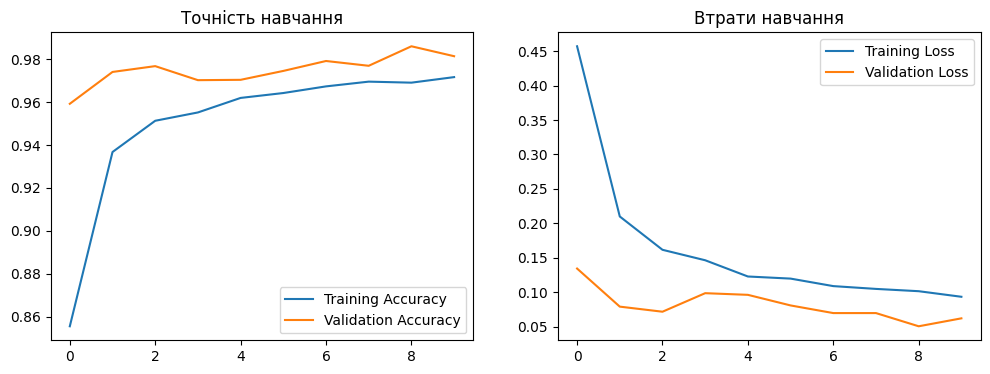

In [35]:
# збереження моделі для веб-застосунку
model.save('mnist_model.h5')
print("\nМодель збережена як mnist_model.h5")

# візуалізація графіків навчання
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Точність навчання')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Втрати навчання')
plt.legend()
plt.show()

##### 7. Оцінка якості на валідаційній вибірці

У цьому розділі розраховуються фінальні метрики: Precision, Recall та F1-Score. Генерація матриці помилок (Confusion Matrix) допомагає візуально визначити, які саме цифри модель плутає найчастіше.


Генерація звіту класифікації...

--- Основні метрики моделі ---
Accuracy (Точність загальна): 0.9823
Precision (Точність прогнозу): 0.9823
Recall (Повнота):             0.9823
F1-Score (Збалансована):      0.9823
------------------------------

Детальний звіт по кожному класу:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       628
           1       1.00      0.99      0.99       710
           2       0.98      0.99      0.98       646
           3       0.98      0.99      0.99       668
           4       0.99      0.96      0.97       637
           5       0.97      0.97      0.97       527
           6       0.99      0.98      0.98       615
           7       0.98      0.98      0.98       661
           8       0.97      0.97      0.97       602
           9       0.97      0.98      0.97       626

    accuracy                           0.98      6320
   macro avg       0.98      0.98      0.98      6320
weighted avg     

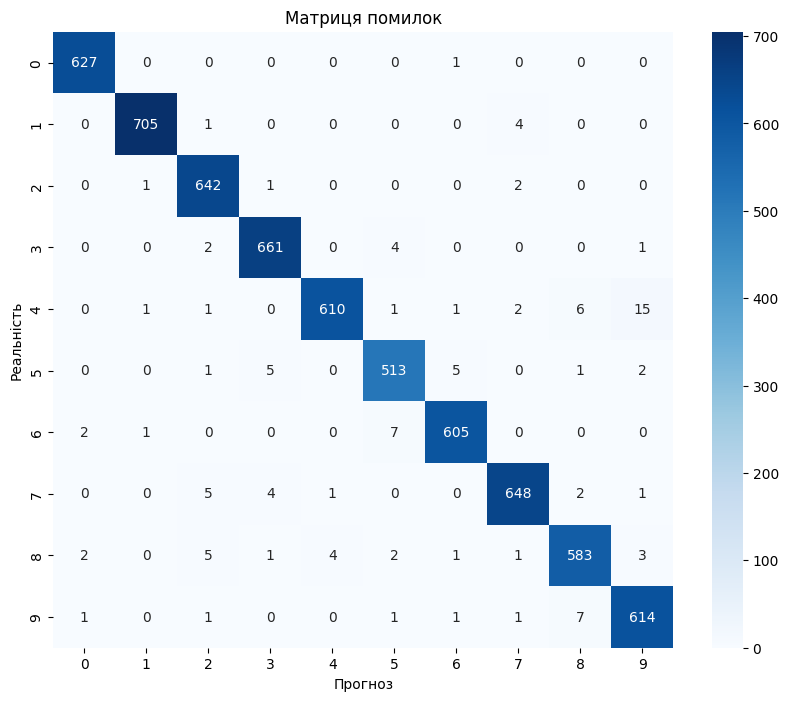

In [36]:
# оцінка якості та Confusion Matrix
print("\nГенерація звіту класифікації...")
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)

print("\n--- Основні метрики моделі ---")
print(f"Accuracy (Точність загальна): {accuracy:.4f}")
print(f"Precision (Точність прогнозу): {precision:.4f}")
print(f"Recall (Повнота):             {recall:.4f}")
print(f"F1-Score (Збалансована):      {f1:.4f}")
print("------------------------------\n")

print("Детальний звіт по кожному класу:")
print(classification_report(y_true, y_pred))

# побудова Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Прогноз')
plt.ylabel('Реальність')
plt.title('Матриця помилок')
plt.show()

##### 8. Тестування та візуалізація прогнозів

Фінальна перевірка моделі на випадкових зображеннях із тестового набору. Виводиться зображення цифри разом із прогнозом моделі та реальною відповіддю, щоб переконатися у практичній придатності системи.


Демонстрація прогнозів:


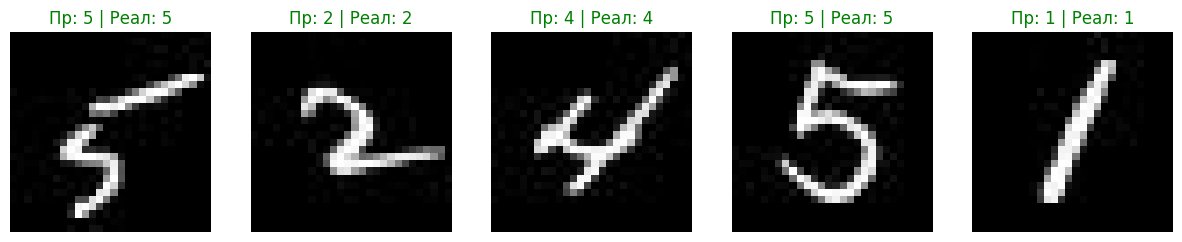

In [37]:
# перевірка на випадкових зображеннях
def plot_actual_vs_predicted(dataset, model, n=5):
    random_ds = dataset.shuffle(buffer_size=1000)
    plt.figure(figsize=(15, 4))

    for images, labels in random_ds.take(1):
        predictions = model.predict(images, verbose=0)

        batch_size = images.shape[0]
        random_indices = np.random.choice(batch_size, n, replace=False)

        for i, idx in enumerate(random_indices):
            plt.subplot(1, n, i+1)
            img = images[idx].numpy().astype("uint8").squeeze()
            plt.imshow(img, cmap='gray')  
                      
            pred_label = np.argmax(predictions[idx])
            true_label = labels[idx].numpy()
            
            color = 'green' if pred_label == true_label else 'red'
            plt.title(f"Пр: {pred_label} | Реал: {true_label}", color=color)
            plt.axis('off')
    plt.show()

print("\nДемонстрація прогнозів:")
plot_actual_vs_predicted(test_ds, model)